In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('titanic_train.csv')
print("Размер датасета:", df.shape)
print("\nПервые строки:")
df.head()

Размер датасета: (981, 12)

Первые строки:


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,home.dest
0,3,1,"Smyth, Miss. Julia",female,NaN,0,0,335432,7.7333,NaN,Q,NaN
1,3,1,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q,"Co Clare, Ireland Washington, DC"
2,3,1,"Whabee, Mrs. George Joseph (Shawneene Abi-Saab)",female,38.0,0,0,2688,7.2292,NaN,C,NaN
3,3,0,"Vovk, Mr. Janko",male,22.0,0,0,349252,7.8958,NaN,S,NaN
4,3,0,"de Pelsmaeker, Mr. Alfons",male,16.0,0,0,345778,9.5000,NaN,S,NaN


In [3]:
# Информация о датасете
print("Информация о признаках:")
print(df.info())
print("\n" + "="*50)
print("\nСтатистика по признакам:")
print(df.describe())
print("\n" + "="*50)
print("\nПропущенные значения:")
print(df.isnull().sum())

Информация о признаках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 981 entries, 0 to 980
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     981 non-null    int64  
 1   survived   981 non-null    int64  
 2   name       981 non-null    object 
 3   sex        981 non-null    object 
 4   age        782 non-null    float64
 5   sibsp      981 non-null    int64  
 6   parch      981 non-null    int64  
 7   ticket     981 non-null    object 
 8   fare       981 non-null    float64
 9   cabin      212 non-null    object 
 10  embarked   981 non-null    object 
 11  home.dest  567 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 92.1+ KB
None


Статистика по признакам:
           pclass    survived         age       sibsp       parch        fare
count  981.000000  981.000000  782.000000  981.000000  981.000000  981.000000
mean     2.299694    0.382263   29.963448    0.480122    0.3

In [4]:
# Анализ выживаемости
print("Распределение выживших:")
print(df['survived'].value_counts())
print(f"\nПроцент выживших: {df['survived'].mean()*100:.2f}%")

print("\n" + "="*50)
print("\nВыживаемость по полу:")
print(df.groupby('sex')['survived'].agg(['count', 'sum', 'mean']))

print("\n" + "="*50)
print("\nВыживаемость по классу:")
print(df.groupby('pclass')['survived'].agg(['count', 'sum', 'mean']))

Распределение выживших:
survived
0    606
1    375
Name: count, dtype: int64

Процент выживших: 38.23%


Выживаемость по полу:
        count  sum      mean
sex                         
female    345  249  0.721739
male      636  126  0.198113


Выживаемость по классу:
        count  sum      mean
pclass                      
1         240  146  0.608333
2         207   86  0.415459
3         534  143  0.267790


In [5]:
# Подготовка признаков для модели
# Выбираем признаки для обучения
features_to_use = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

# Создаем копию данных
df_model = df[features_to_use + ['survived']].copy()

# Заполняем пропущенные значения
df_model['age'].fillna(df_model['age'].median(), inplace=True)

# Кодируем категориальные признаки
df_model['sex'] = df_model['sex'].map({'male': 0, 'female': 1})
df_model = pd.get_dummies(df_model, columns=['embarked'], drop_first=True)

print("Подготовленные данные:")
print(df_model.head())
print(f"\nРазмер: {df_model.shape}")
print(f"\nПризнаки: {list(df_model.columns)}")
print(f"\nПропущенные значения:\n{df_model.isnull().sum()}")

Подготовленные данные:
   pclass  sex   age  sibsp  parch    fare  survived  embarked_Q  embarked_S
0       3    1  28.0      0      0  7.7333         1        True       False
1       3    1  28.0      0      0  7.7500         1        True       False
2       3    1  38.0      0      0  7.2292         1       False       False
3       3    0  22.0      0      0  7.8958         0       False        True
4       3    0  16.0      0      0  9.5000         0       False        True

Размер: (981, 9)

Признаки: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'survived', 'embarked_Q', 'embarked_S']

Пропущенные значения:
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
survived      0
embarked_Q    0
embarked_S    0
dtype: int64


/tmp/ipykernel_1263226/181845708.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model['age'].fillna(df_model['age'].median(), inplace=True)


In [6]:
# Разделение на признаки и целевую переменную
X = df_model.drop('survived', axis=1)
y = df_model['survived']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# Обучение модели логистической регрессии
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("\nМодель обучена!")
print(f"Коэффициенты модели: {model.coef_}")
print(f"Свободный член: {model.intercept_}")

Размер обучающей выборки: (784, 8)
Размер тестовой выборки: (197, 8)

Модель обучена!
Коэффициенты модели: [[-8.47827561e-01  2.31579140e+00 -3.09906728e-02 -3.43634063e-01
  -4.27444748e-02  1.77378556e-03 -5.26458403e-01 -6.26415147e-01]]
Свободный член: [2.0325115]


In [7]:
# Предсказания на обучающей и тестовой выборках
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Оценка качества
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("="*60)
print("РЕЗУЛЬТАТЫ МОДЕЛИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ")
print("="*60)
print(f"\nТочность на обучающей выборке: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Точность на тестовой выборке: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print("\n" + "="*60)
print("Матрица ошибок (тестовая выборка):")
print("="*60)
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print(f"\nИстинные негативы (TN): {cm[0,0]}")
print(f"Ложные позитивы (FP): {cm[0,1]}")
print(f"Ложные негативы (FN): {cm[1,0]}")
print(f"Истинные позитивы (TP): {cm[1,1]}")

print("\n" + "="*60)
print("Отчет классификации (тестовая выборка):")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Погиб', 'Выжил']))

РЕЗУЛЬТАТЫ МОДЕЛИ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ

Точность на обучающей выборке: 0.7793 (77.93%)
Точность на тестовой выборке: 0.8325 (83.25%)

Матрица ошибок (тестовая выборка):
[[100  14]
 [ 19  64]]

Истинные негативы (TN): 100
Ложные позитивы (FP): 14
Ложные негативы (FN): 19
Истинные позитивы (TP): 64

Отчет классификации (тестовая выборка):
              precision    recall  f1-score   support

       Погиб       0.84      0.88      0.86       114
       Выжил       0.82      0.77      0.80        83

    accuracy                           0.83       197
   macro avg       0.83      0.82      0.83       197
weighted avg       0.83      0.83      0.83       197



ВАЖНОСТЬ ПРИЗНАКОВ (по абсолютному значению коэффициента)
   Признак  Коэффициент  Абсолютное значение
       sex     2.315791             2.315791
    pclass    -0.847828             0.847828
embarked_S    -0.626415             0.626415
embarked_Q    -0.526458             0.526458
     sibsp    -0.343634             0.343634
     parch    -0.042744             0.042744
       age    -0.030991             0.030991
      fare     0.001774             0.001774


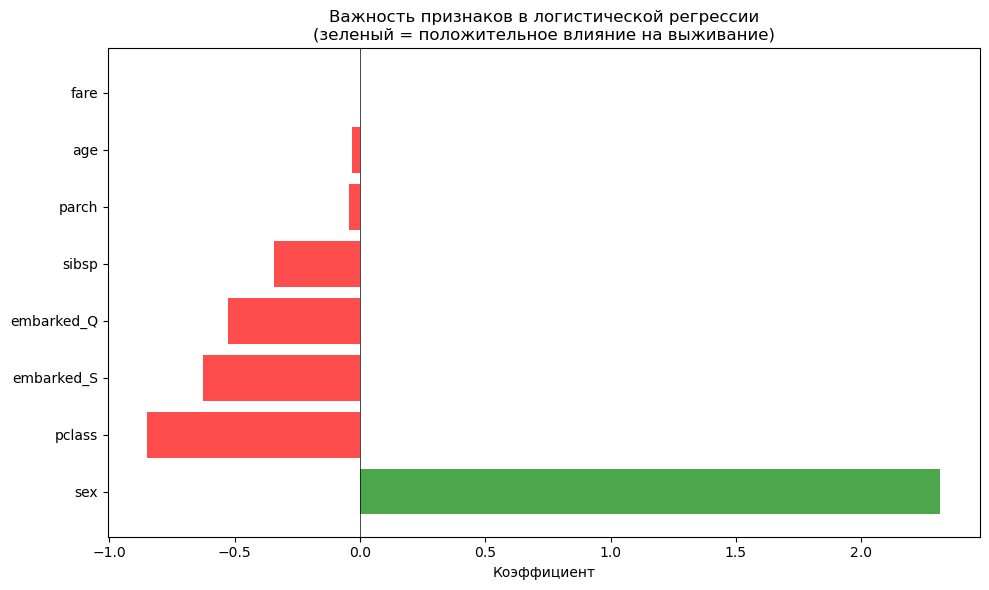

In [8]:
# Важность признаков (коэффициенты модели)
feature_names = X.columns
coefficients = model.coef_[0]

# Создаем DataFrame для удобства визуализации
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': coefficients,
    'Абсолютное значение': np.abs(coefficients)
}).sort_values('Абсолютное значение', ascending=False)

print("="*60)
print("ВАЖНОСТЬ ПРИЗНАКОВ (по абсолютному значению коэффициента)")
print("="*60)
print(feature_importance.to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Коэффициент']]
plt.barh(feature_importance['Признак'], feature_importance['Коэффициент'], color=colors, alpha=0.7)
plt.xlabel('Коэффициент')
plt.title('Важность признаков в логистической регрессии\n(зеленый = положительное влияние на выживание)')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [9]:
# Интерпретация результатов
print("="*60)
print("ИНТЕРПРЕТАЦИЯ МОДЕЛИ")
print("="*60)

print("\nВлияние признаков на вероятность выживания:")
print("-" * 60)

for idx, row in feature_importance.iterrows():
    feature = row['Признак']
    coef = row['Коэффициент']
    
    if coef > 0:
        print(f"✓ {feature:12s}: +{coef:.4f} (повышает шансы на выживание)")
    else:
        print(f"✗ {feature:12s}: {coef:.4f} (снижает шансы на выживание)")

print("\n" + "="*60)
print("ОСНОВНЫЕ ВЫВОДЫ:")
print("="*60)
print("""
1. ПОЛ (sex = +2.32) - самый важный фактор:
   Женщины имели значительно больше шансов на выживание
   
2. КЛАСС (pclass = -0.85):
   Чем выше класс (меньше число), тем выше шансы на выживание
   Пассажиры 1-го класса выживали чаще
   
3. ПОРТ ПОСАДКИ (embarked):
   Порт посадки также влиял на выживаемость
   
4. РОДСТВЕННИКИ (sibsp, parch):
   Наличие многих родственников снижало шансы на выживание
   
5. ВОЗРАСТ и СТОИМОСТЬ БИЛЕТА имели меньшее влияние
""")

ИНТЕРПРЕТАЦИЯ МОДЕЛИ

Влияние признаков на вероятность выживания:
------------------------------------------------------------
✓ sex         : +2.3158 (повышает шансы на выживание)
✗ pclass      : -0.8478 (снижает шансы на выживание)
✗ embarked_S  : -0.6264 (снижает шансы на выживание)
✗ embarked_Q  : -0.5265 (снижает шансы на выживание)
✗ sibsp       : -0.3436 (снижает шансы на выживание)
✗ parch       : -0.0427 (снижает шансы на выживание)
✗ age         : -0.0310 (снижает шансы на выживание)
✓ fare        : +0.0018 (повышает шансы на выживание)

ОСНОВНЫЕ ВЫВОДЫ:

1. ПОЛ (sex = +2.32) - самый важный фактор:
   Женщины имели значительно больше шансов на выживание

2. КЛАСС (pclass = -0.85):
   Чем выше класс (меньше число), тем выше шансы на выживание
   Пассажиры 1-го класса выживали чаще

3. ПОРТ ПОСАДКИ (embarked):
   Порт посадки также влиял на выживаемость

4. РОДСТВЕННИКИ (sibsp, parch):
   Наличие многих родственников снижало шансы на выживание

5. ВОЗРАСТ и СТОИМОСТЬ БИЛЕТА име

In [10]:
# Примеры предсказаний для разных типов пассажиров
print("="*60)
print("ПРИМЕРЫ ПРЕДСКАЗАНИЙ")
print("="*60)

# Пример 1: Женщина, 1 класс
example1 = pd.DataFrame({
    'pclass': [1],
    'sex': [1],  # female
    'age': [30],
    'sibsp': [0],
    'parch': [0],
    'fare': [50],
    'embarked_Q': [False],
    'embarked_S': [False]
})
prob1 = model.predict_proba(example1)[0]
pred1 = model.predict(example1)[0]

print("\n1. Женщина, 30 лет, 1 класс, без родственников:")
print(f"   Вероятность выживания: {prob1[1]:.2%}")
print(f"   Предсказание: {'ВЫЖИЛ ✓' if pred1 == 1 else 'ПОГИБ ✗'}")

# Пример 2: Мужчина, 3 класс
example2 = pd.DataFrame({
    'pclass': [3],
    'sex': [0],  # male
    'age': [25],
    'sibsp': [0],
    'parch': [0],
    'fare': [7],
    'embarked_Q': [False],
    'embarked_S': [True]
})
prob2 = model.predict_proba(example2)[0]
pred2 = model.predict(example2)[0]

print("\n2. Мужчина, 25 лет, 3 класс, без родственников:")
print(f"   Вероятность выживания: {prob2[1]:.2%}")
print(f"   Предсказание: {'ВЫЖИЛ ✓' if pred2 == 1 else 'ПОГИБ ✗'}")

# Пример 3: Ребенок, 1 класс
example3 = pd.DataFrame({
    'pclass': [1],
    'sex': [1],  # female
    'age': [5],
    'sibsp': [1],
    'parch': [2],
    'fare': [100],
    'embarked_Q': [False],
    'embarked_S': [False]
})
prob3 = model.predict_proba(example3)[0]
pred3 = model.predict(example3)[0]

print("\n3. Девочка, 5 лет, 1 класс, с родителями:")
print(f"   Вероятность выживания: {prob3[1]:.2%}")
print(f"   Предсказание: {'ВЫЖИЛ ✓' if pred3 == 1 else 'ПОГИБ ✗'}")

# Пример 4: Пожилой мужчина, 2 класс
example4 = pd.DataFrame({
    'pclass': [2],
    'sex': [0],  # male
    'age': [60],
    'sibsp': [0],
    'parch': [0],
    'fare': [20],
    'embarked_Q': [False],
    'embarked_S': [True]
})
prob4 = model.predict_proba(example4)[0]
pred4 = model.predict(example4)[0]

print("\n4. Пожилой мужчина, 60 лет, 2 класс, без родственников:")
print(f"   Вероятность выживания: {prob4[1]:.2%}")
print(f"   Предсказание: {'ВЫЖИЛ ✓' if pred4 == 1 else 'ПОГИБ ✗'}")

print("\n" + "="*60)

ПРИМЕРЫ ПРЕДСКАЗАНИЙ

1. Женщина, 30 лет, 1 класс, без родственников:
   Вероятность выживания: 93.46%
   Предсказание: ВЫЖИЛ ✓

2. Мужчина, 25 лет, 3 класс, без родственников:
   Вероятность выживания: 13.01%
   Предсказание: ПОГИБ ✗

3. Девочка, 5 лет, 1 класс, с родителями:
   Вероятность выживания: 95.66%
   Предсказание: ВЫЖИЛ ✓

4. Пожилой мужчина, 60 лет, 2 класс, без родственников:
   Вероятность выживания: 10.78%
   Предсказание: ПОГИБ ✗



In [11]:
# Финальное резюме
print("="*70)
print(" "*15 + "РЕЗЮМЕ АНАЛИЗА TITANIC")
print("="*70)

print(f"""
📊 ДАННЫЕ:
   • Всего пассажиров: {len(df)}
   • Выжило: {df['survived'].sum()} ({df['survived'].mean()*100:.1f}%)
   • Погибло: {len(df) - df['survived'].sum()} ({(1-df['survived'].mean())*100:.1f}%)

🤖 МОДЕЛЬ: Логистическая регрессия (sklearn.linear_model.LogisticRegression)
   • Обучающая выборка: {len(X_train)} пассажиров
   • Тестовая выборка: {len(X_test)} пассажиров

📈 КАЧЕСТВО МОДЕЛИ:
   • Точность на обучающей выборке: {train_accuracy*100:.2f}%
   • Точность на тестовой выборке: {test_accuracy*100:.2f}%
   
🔑 КЛЮЧЕВЫЕ ФАКТОРЫ ВЫЖИВАНИЯ:
   1. ПОЛ - женщины выживали значительно чаще (72% vs 20% мужчин)
   2. КЛАСС - пассажиры 1-го класса имели больше шансов (61% vs 27% в 3-м)
   3. Порт посадки, количество родственников, возраст

💡 ИСТОРИЧЕСКИЙ КОНТЕКСТ:
   При эвакуации Титаника применялся принцип "женщины и дети первыми",
   что отразилось в данных и хорошо улавливается моделью.
""")

print("="*70)

               РЕЗЮМЕ АНАЛИЗА TITANIC

📊 ДАННЫЕ:
   • Всего пассажиров: 981
   • Выжило: 375 (38.2%)
   • Погибло: 606 (61.8%)

🤖 МОДЕЛЬ: Логистическая регрессия (sklearn.linear_model.LogisticRegression)
   • Обучающая выборка: 784 пассажиров
   • Тестовая выборка: 197 пассажиров

📈 КАЧЕСТВО МОДЕЛИ:
   • Точность на обучающей выборке: 77.93%
   • Точность на тестовой выборке: 83.25%

🔑 КЛЮЧЕВЫЕ ФАКТОРЫ ВЫЖИВАНИЯ:
   1. ПОЛ - женщины выживали значительно чаще (72% vs 20% мужчин)
   2. КЛАСС - пассажиры 1-го класса имели больше шансов (61% vs 27% в 3-м)
   3. Порт посадки, количество родственников, возраст

💡 ИСТОРИЧЕСКИЙ КОНТЕКСТ:
   При эвакуации Титаника применялся принцип "женщины и дети первыми",
   что отразилось в данных и хорошо улавливается моделью.



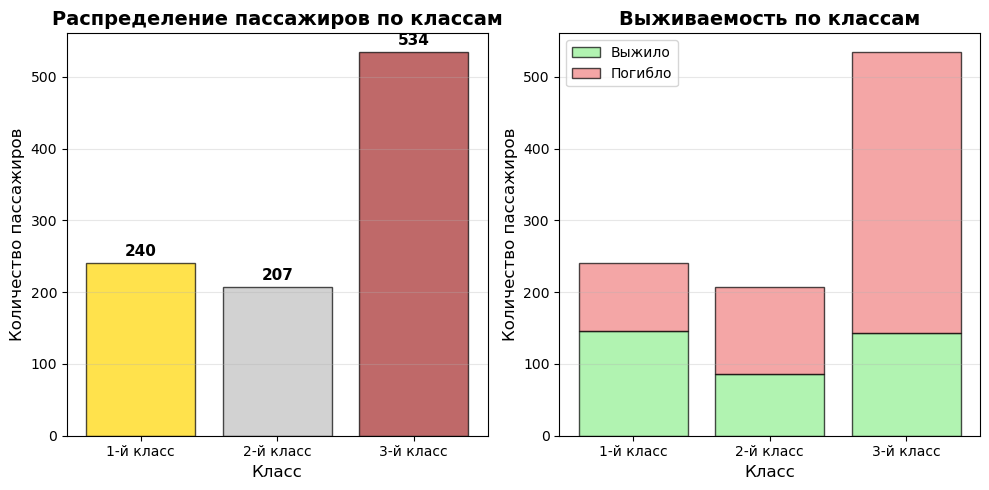

РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:
1-й класс: 240 пассажиров (24.5%)
2-й класс: 207 пассажиров (21.1%)
3-й класс: 534 пассажиров (54.4%)


In [13]:
# Гистограмма распределения объектов по классам
plt.figure(figsize=(10, 5))

# Подграфик 1: Распределение по классам
plt.subplot(1, 2, 1)
class_counts = df['pclass'].value_counts().sort_index()
plt.bar(class_counts.index, class_counts.values, color=['gold', 'silver', 'brown'], alpha=0.7, edgecolor='black')
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.title('Распределение пассажиров по классам', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3], ['1-й класс', '2-й класс', '3-й класс'])
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(class_counts.values):
    plt.text(class_counts.index[i], v + 10, str(v), ha='center', fontsize=11, fontweight='bold')

# Подграфик 2: Распределение выживших по классам
plt.subplot(1, 2, 2)
survival_by_class = df.groupby('pclass')['survived'].sum().sort_index()
plt.bar(survival_by_class.index, survival_by_class.values, color=['lightgreen', 'lightgreen', 'lightgreen'], 
        alpha=0.7, edgecolor='black', label='Выжило')
plt.bar(class_counts.index, class_counts.values - survival_by_class.values, 
        bottom=survival_by_class.values, color=['lightcoral', 'lightcoral', 'lightcoral'], 
        alpha=0.7, edgecolor='black', label='Погибло')
plt.xlabel('Класс', fontsize=12)
plt.ylabel('Количество пассажиров', fontsize=12)
plt.title('Выживаемость по классам', fontsize=14, fontweight='bold')
plt.xticks([1, 2, 3], ['1-й класс', '2-й класс', '3-й класс'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("="*60)
print("РАСПРЕДЕЛЕНИЕ ПО КЛАССАМ:")
print("="*60)
for pclass in sorted(df['pclass'].unique()):
    count = len(df[df['pclass'] == pclass])
    percent = count / len(df) * 100
    print(f"{pclass}-й класс: {count} пассажиров ({percent:.1f}%)")


In [14]:
# Вычисление доли выживших
total_passengers = len(df)
survived_count = df['survived'].sum()
survival_rate = df['survived'].mean()

print("="*60)
print("ДОЛЯ ВЫЖИВШИХ:")
print("="*60)
print(f"Всего пассажиров: {total_passengers}")
print(f"Выжило: {survived_count}")
print(f"Погибло: {total_passengers - survived_count}")
print(f"\nДоля выживших: {survival_rate:.4f} или {survival_rate*100:.2f}%")
print(f"Доля погибших: {1-survival_rate:.4f} или {(1-survival_rate)*100:.2f}%")
print("="*60)

ДОЛЯ ВЫЖИВШИХ:
Всего пассажиров: 981
Выжило: 375
Погибло: 606

Доля выживших: 0.3823 или 38.23%
Доля погибших: 0.6177 или 61.77%


In [15]:
# Определяем долю пропущенных значений для каждого признака
print("="*60)
print("ДОЛЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ПО ПРИЗНАКАМ:")
print("="*60)

missing_stats = pd.DataFrame({
    'Признак': df.columns,
    'Пропусков': df.isnull().sum(),
    'Доля': df.isnull().sum() / len(df)
}).sort_values('Доля', ascending=False)

print(missing_stats.to_string(index=False))

# Определяем признаки с пропусками > 1/3
threshold = 1/3
features_to_drop = missing_stats[missing_stats['Доля'] > threshold]['Признак'].tolist()

print(f"\n{'='*60}")
print(f"Признаки с долей пропусков > {threshold:.2%}:")
print("="*60)
for feature in features_to_drop:
    missing_pct = missing_stats[missing_stats['Признак'] == feature]['Доля'].values[0]
    print(f"  • {feature}: {missing_pct:.2%}")

# Также удаляем ticket
features_to_drop.append('ticket')
print(f"\nДополнительно удаляем: ticket")
print(f"\nВсего удаляем признаков: {len(features_to_drop)}")
print(f"Признаки к удалению: {features_to_drop}")

ДОЛЯ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ ПО ПРИЗНАКАМ:
  Признак  Пропусков     Доля
    cabin        769 0.783894
home.dest        414 0.422018
      age        199 0.202854
   pclass          0 0.000000
      sex          0 0.000000
     name          0 0.000000
 survived          0 0.000000
    sibsp          0 0.000000
   ticket          0 0.000000
    parch          0 0.000000
     fare          0 0.000000
 embarked          0 0.000000

Признаки с долей пропусков > 33.33%:
  • cabin: 78.39%
  • home.dest: 42.20%

Дополнительно удаляем: ticket

Всего удаляем признаков: 3
Признаки к удалению: ['cabin', 'home.dest', 'ticket']


In [16]:
# Удаляем признаки
df_cleaned = df.drop(columns=features_to_drop)

print("="*60)
print("ДАТАСЕТ ПОСЛЕ УДАЛЕНИЯ ПРИЗНАКОВ:")
print("="*60)
print(f"Размер до: {df.shape}")
print(f"Размер после: {df_cleaned.shape}")
print(f"\nОставшиеся признаки: {list(df_cleaned.columns)}")
print(f"\nПропущенные значения:")
print(df_cleaned.isnull().sum())

ДАТАСЕТ ПОСЛЕ УДАЛЕНИЯ ПРИЗНАКОВ:
Размер до: (981, 12)
Размер после: (981, 9)

Оставшиеся признаки: ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Пропущенные значения:
pclass        0
survived      0
name          0
sex           0
age         199
sibsp         0
parch         0
fare          0
embarked      0
dtype: int64


In [17]:
# Создаем новый признак fam_size как сумму sibsp и parch
df_cleaned['fam_size'] = df_cleaned['sibsp'] + df_cleaned['parch']

# Удаляем исходные колонки sibsp и parch
df_cleaned = df_cleaned.drop(columns=['sibsp', 'parch'])

print("="*60)
print("СОЗДАНИЕ ПРИЗНАКА fam_size:")
print("="*60)
print(f"Формула: fam_size = sibsp + parch")
print(f"\nПервые 10 значений:")
print(df_cleaned[['name', 'fam_size']].head(10))

print(f"\n{'='*60}")
print("СТАТИСТИКА fam_size:")
print("="*60)
print(df_cleaned['fam_size'].describe())

# Вычисляем выборочное среднее
fam_size_mean = df_cleaned['fam_size'].mean()

print(f"\n{'='*60}")
print(f"ВЫБОРОЧНОЕ СРЕДНЕЕ fam_size: {fam_size_mean:.6f}")
print("="*60)

print(f"\nОкончательная структура датасета:")
print(f"Размер: {df_cleaned.shape}")
print(f"Признаки: {list(df_cleaned.columns)}")

СОЗДАНИЕ ПРИЗНАКА fam_size:
Формула: fam_size = sibsp + parch

Первые 10 значений:
                                              name  fam_size
0                               Smyth, Miss. Julia         0
1                         Glynn, Miss. Mary Agatha         0
2  Whabee, Mrs. George Joseph (Shawneene Abi-Saab)         0
3                                  Vovk, Mr. Janko         0
4                        de Pelsmaeker, Mr. Alfons         0
5                         Daly, Mr. Eugene Patrick         0
6                           Wiseman, Mr. Phillippe         0
7                              Birnbaum, Mr. Jakob         0
8                                 Danoff, Mr. Yoto         0
9                     Asplund, Master. Filip Oscar         6

СТАТИСТИКА fam_size:
count    981.000000
mean       0.866463
std        1.552321
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max       10.000000
Name: fam_size, dtype: float64

ВЫБОРОЧНОЕ СРЕДНЕЕ fam_size: 0.8

In [18]:
# Определяем число предикторов
# Предикторы - это все признаки кроме целевой переменной (survived) и неинформативных (name)

print("="*60)
print("ИСХОДНЫЙ ДАТАСЕТ:")
print("="*60)
print(f"Размер: {df_cleaned.shape}")
print(f"Все признаки: {list(df_cleaned.columns)}")

# Целевая переменная
target = 'survived'

# Неинформативные признаки (имя не используется для предсказания)
non_predictors = ['survived', 'name']

# Предикторы
predictors = [col for col in df_cleaned.columns if col not in non_predictors]

print(f"\n{'='*60}")
print("ПРЕДИКТОРЫ:")
print("="*60)
print(f"Целевая переменная: {target}")
print(f"Неинформативные: {non_predictors}")
print(f"\nПредикторы: {predictors}")

num_predictors = len(predictors)
print(f"\n{'='*60}")
print(f"ЧИСЛО ПРЕДИКТОРОВ: {num_predictors}")
print("="*60)

# Дополнительная информация о предикторах
print(f"\nТипы предикторов:")
for pred in predictors:
    dtype = df_cleaned[pred].dtype
    unique_count = df_cleaned[pred].nunique()
    print(f"  • {pred:12s}: {str(dtype):10s} (уникальных значений: {unique_count})")

ИСХОДНЫЙ ДАТАСЕТ:
Размер: (981, 8)
Все признаки: ['pclass', 'survived', 'name', 'sex', 'age', 'fare', 'embarked', 'fam_size']

ПРЕДИКТОРЫ:
Целевая переменная: survived
Неинформативные: ['survived', 'name']

Предикторы: ['pclass', 'sex', 'age', 'fare', 'embarked', 'fam_size']

ЧИСЛО ПРЕДИКТОРОВ: 6

Типы предикторов:
  • pclass      : int64      (уникальных значений: 3)
  • sex         : object     (уникальных значений: 2)
  • age         : float64    (уникальных значений: 92)
  • fare        : float64    (уникальных значений: 254)
  • embarked    : object     (уникальных значений: 3)
  • fam_size    : int64      (уникальных значений: 9)


In [19]:
# Оценка вероятности выжить для категории: female and pclass:1
# Вероятность = (число выживших в категории) / (общее число в категории)

# Фильтруем данные по условию
category_mask = (df_cleaned['sex'] == 'female') & (df_cleaned['pclass'] == 1)
category_data = df_cleaned[category_mask]

# Вычисляем статистику
total_in_category = len(category_data)
survived_in_category = category_data['survived'].sum()
survival_probability = category_data['survived'].mean()

print("="*60)
print("ОЦЕНКА ВЕРОЯТНОСТИ ВЫЖИВАНИЯ")
print("Категория: female AND pclass = 1")
print("="*60)

print(f"\nВсего пассажиров в категории: {total_in_category}")
print(f"Выжило: {survived_in_category}")
print(f"Погибло: {total_in_category - survived_in_category}")

print(f"\n{'='*60}")
print(f"ВЕРОЯТНОСТЬ ВЫЖИТЬ: {survival_probability:.6f}")
print(f"                     {survival_probability*100:.2f}%")
print("="*60)

# Дополнительная информация для контекста
print(f"\nДля сравнения:")
print(f"  • Общая вероятность выжить: {df_cleaned['survived'].mean():.2%}")
print(f"  • Вероятность для всех женщин: {df_cleaned[df_cleaned['sex'] == 'female']['survived'].mean():.2%}")
print(f"  • Вероятность для 1-го класса: {df_cleaned[df_cleaned['pclass'] == 1]['survived'].mean():.2%}")

ОЦЕНКА ВЕРОЯТНОСТИ ВЫЖИВАНИЯ
Категория: female AND pclass = 1

Всего пассажиров в категории: 104
Выжило: 101
Погибло: 3

ВЕРОЯТНОСТЬ ВЫЖИТЬ: 0.971154
                     97.12%

Для сравнения:
  • Общая вероятность выжить: 38.23%
  • Вероятность для всех женщин: 72.17%
  • Вероятность для 1-го класса: 60.83%


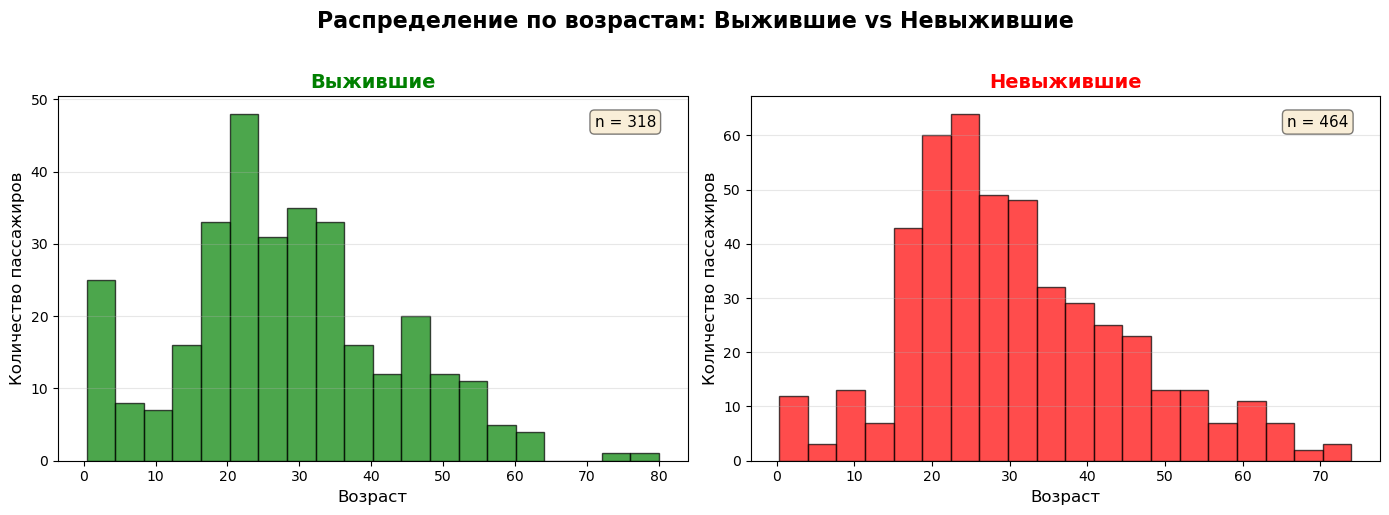

СТАТИСТИКА ПО ВОЗРАСТАМ:

Выжившие (n=318):
  Средний возраст: 28.65 лет
  Медианный возраст: 27.00 лет
  Мин: 0.42, Макс: 80.00

Невыжившие (n=464):
  Средний возраст: 30.86 лет
  Медианный возраст: 28.00 лет
  Мин: 0.33, Макс: 74.00


In [20]:
# Гистограммы выживших и невыживших по возрастам

# Убираем пропущенные значения возраста для построения гистограмм
df_with_age = df_cleaned.dropna(subset=['age'])

# Разделяем на выживших и невыживших
survived_ages = df_with_age[df_with_age['survived'] == 1]['age']
not_survived_ages = df_with_age[df_with_age['survived'] == 0]['age']

# Создаем фигуру с двумя подграфиками
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма 1: Выжившие
axes[0].hist(survived_ages, bins=20, color='green', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Возраст', fontsize=12)
axes[0].set_ylabel('Количество пассажиров', fontsize=12)
axes[0].set_title('Выжившие', fontsize=14, fontweight='bold', color='green')
axes[0].grid(axis='y', alpha=0.3)
axes[0].text(0.95, 0.95, f'n = {len(survived_ages)}', 
             transform=axes[0].transAxes, ha='right', va='top', 
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Гистограмма 2: Невыжившие
axes[1].hist(not_survived_ages, bins=20, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Возраст', fontsize=12)
axes[1].set_ylabel('Количество пассажиров', fontsize=12)
axes[1].set_title('Невыжившие', fontsize=14, fontweight='bold', color='red')
axes[1].grid(axis='y', alpha=0.3)
axes[1].text(0.95, 0.95, f'n = {len(not_survived_ages)}', 
             transform=axes[1].transAxes, ha='right', va='top', 
             fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Распределение по возрастам: Выжившие vs Невыжившие', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Статистика
print("="*60)
print("СТАТИСТИКА ПО ВОЗРАСТАМ:")
print("="*60)
print(f"\nВыжившие (n={len(survived_ages)}):")
print(f"  Средний возраст: {survived_ages.mean():.2f} лет")
print(f"  Медианный возраст: {survived_ages.median():.2f} лет")
print(f"  Мин: {survived_ages.min():.2f}, Макс: {survived_ages.max():.2f}")

print(f"\nНевыжившие (n={len(not_survived_ages)}):")
print(f"  Средний возраст: {not_survived_ages.mean():.2f} лет")
print(f"  Медианный возраст: {not_survived_ages.median():.2f} лет")
print(f"  Мин: {not_survived_ages.min():.2f}, Макс: {not_survived_ages.max():.2f}")
print("="*60)

In [21]:
# Шаг 1: Отбираем только числовые признаки
numeric_columns = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()

print("="*60)
print("ОТБОР ЧИСЛОВЫХ ПРИЗНАКОВ:")
print("="*60)
print(f"Все признаки: {list(df_cleaned.columns)}")
print(f"\nЧисловые признаки: {numeric_columns}")

# Создаем датасет только с числовыми признаками
df_numeric = df_cleaned[numeric_columns].copy()

print(f"\nРазмер датасета с числовыми признаками: {df_numeric.shape}")
print(f"\nПропущенные значения:")
print(df_numeric.isnull().sum())

ОТБОР ЧИСЛОВЫХ ПРИЗНАКОВ:
Все признаки: ['pclass', 'survived', 'name', 'sex', 'age', 'fare', 'embarked', 'fam_size']

Числовые признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size']

Размер датасета с числовыми признаками: (981, 5)

Пропущенные значения:
pclass        0
survived      0
age         199
fare          0
fam_size      0
dtype: int64


In [22]:
# Шаг 2: Удаляем строки с пропусками
df_numeric_clean = df_numeric.dropna()

print("="*60)
print("УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ:")
print("="*60)
print(f"Размер до удаления: {df_numeric.shape}")
print(f"Размер после удаления: {df_numeric_clean.shape}")
print(f"Удалено строк: {len(df_numeric) - len(df_numeric_clean)}")

print(f"\nПропущенные значения после очистки:")
print(df_numeric_clean.isnull().sum())

print(f"\nПервые 5 строк:")
print(df_numeric_clean.head())

УДАЛЕНИЕ СТРОК С ПРОПУСКАМИ:
Размер до удаления: (981, 5)
Размер после удаления: (782, 5)
Удалено строк: 199

Пропущенные значения после очистки:
pclass      0
survived    0
age         0
fare        0
fam_size    0
dtype: int64

Первые 5 строк:
   pclass  survived   age     fare  fam_size
2       3         1  38.0   7.2292         0
3       3         0  22.0   7.8958         0
4       3         0  16.0   9.5000         0
5       3         1  29.0   7.7500         0
7       1         0  25.0  26.0000         0


In [23]:
from sklearn.metrics import f1_score

# Шаг 3: Разделяем на признаки и целевую переменную
X = df_numeric_clean.drop('survived', axis=1)
y = df_numeric_clean['survived']

print("="*60)
print("РАЗДЕЛЕНИЕ ДАННЫХ:")
print("="*60)
print(f"Признаки (X): {list(X.columns)}")
print(f"Целевая переменная (y): survived")
print(f"\nРазмер X: {X.shape}")
print(f"Размер y: {y.shape}")

# Шаг 4: Разбиение на обучающую и тестовую выборки со стратификацией
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=7, 
    stratify=y
)

print(f"\n{'='*60}")
print("TRAIN-TEST SPLIT:")
print("="*60)
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")
print(f"\nРаспределение в обучающей выборке:")
print(y_train.value_counts().sort_index())
print(f"Доля выживших: {y_train.mean():.4f}")
print(f"\nРаспределение в тестовой выборке:")
print(y_test.value_counts().sort_index())
print(f"Доля выживших: {y_test.mean():.4f}")

РАЗДЕЛЕНИЕ ДАННЫХ:
Признаки (X): ['pclass', 'age', 'fare', 'fam_size']
Целевая переменная (y): survived

Размер X: (782, 4)
Размер y: (782,)

TRAIN-TEST SPLIT:
Обучающая выборка: (625, 4)
Тестовая выборка: (157, 4)

Распределение в обучающей выборке:
survived
0    371
1    254
Name: count, dtype: int64
Доля выживших: 0.4064

Распределение в тестовой выборке:
survived
0    93
1    64
Name: count, dtype: int64
Доля выживших: 0.4076


In [24]:
# Шаг 5: Обучение модели LogisticRegression
model_numeric = LogisticRegression(random_state=7, max_iter=1000)
model_numeric.fit(X_train, y_train)

print("="*60)
print("ОБУЧЕНИЕ МОДЕЛИ:")
print("="*60)
print("Модель: LogisticRegression(random_state=7, max_iter=1000)")
print("\nМодель обучена!")
print(f"\nКоэффициенты: {model_numeric.coef_[0]}")
print(f"Признаки: {list(X.columns)}")
print(f"Свободный член: {model_numeric.intercept_[0]:.4f}")

ОБУЧЕНИЕ МОДЕЛИ:
Модель: LogisticRegression(random_state=7, max_iter=1000)

Модель обучена!

Коэффициенты: [-0.88989919 -0.03687272  0.00447711  0.05070702]
Признаки: ['pclass', 'age', 'fare', 'fam_size']
Свободный член: 2.4293


In [25]:
# Шаг 6: Оценка модели на тестовых данных
y_train_pred = model_numeric.predict(X_train)
y_test_pred = model_numeric.predict(X_test)

# Точность
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# F1-score
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("="*60)
print("ОЦЕНКА МОДЕЛИ:")
print("="*60)

print("\nТочность (Accuracy):")
print(f"  Обучающая выборка: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Тестовая выборка: {test_acc:.4f} ({test_acc*100:.2f}%)")

print("\n" + "="*60)
print(f"F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: {test_f1:.6f}")
print("="*60)

print(f"\nДополнительная информация:")
print(f"  F1-score (обучающая): {train_f1:.6f}")
print(f"  F1-score (тестовая): {test_f1:.6f}")

# Матрица ошибок
print(f"\n{'='*60}")
print("Матрица ошибок (тестовая выборка):")
print("="*60)
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print(f"\nTN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")

print(f"\n{'='*60}")
print("Отчет классификации (тестовая выборка):")
print("="*60)
print(classification_report(y_test, y_test_pred, target_names=['Погиб', 'Выжил']))

ОЦЕНКА МОДЕЛИ:

Точность (Accuracy):
  Обучающая выборка: 0.6864 (68.64%)
  Тестовая выборка: 0.6815 (68.15%)

F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: 0.528302

Дополнительная информация:
  F1-score (обучающая): 0.554545
  F1-score (тестовая): 0.528302

Матрица ошибок (тестовая выборка):
[[79 14]
 [36 28]]

TN=79, FP=14, FN=36, TP=28

Отчет классификации (тестовая выборка):
              precision    recall  f1-score   support

       Погиб       0.69      0.85      0.76        93
       Выжил       0.67      0.44      0.53        64

    accuracy                           0.68       157
   macro avg       0.68      0.64      0.64       157
weighted avg       0.68      0.68      0.67       157



In [26]:
# Шаг 1: Отбираем числовые признаки из исходного датасета
df_numeric_v2 = df_cleaned.select_dtypes(include=[np.number]).copy()

print("="*60)
print("ОТБОР ЧИСЛОВЫХ ПРИЗНАКОВ (версия 2):")
print("="*60)
print(f"Числовые признаки: {list(df_numeric_v2.columns)}")
print(f"Размер: {df_numeric_v2.shape}")

print(f"\nПропущенные значения ДО заполнения:")
print(df_numeric_v2.isnull().sum())

ОТБОР ЧИСЛОВЫХ ПРИЗНАКОВ (версия 2):
Числовые признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size']
Размер: (981, 5)

Пропущенные значения ДО заполнения:
pclass        0
survived      0
age         199
fare          0
fam_size      0
dtype: int64


In [27]:
# Шаг 2: Заполняем пропуски средним по столбцу
# Вычисляем среднее для каждого столбца
for col in df_numeric_v2.columns:
    if df_numeric_v2[col].isnull().any():
        mean_value = df_numeric_v2[col].mean()
        df_numeric_v2[col].fillna(mean_value, inplace=True)
        print(f"Заполнены пропуски в столбце '{col}' средним значением: {mean_value:.4f}")

print(f"\n{'='*60}")
print("ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ПОСЛЕ ЗАПОЛНЕНИЯ:")
print("="*60)
print(df_numeric_v2.isnull().sum())

print(f"\nРазмер датасета: {df_numeric_v2.shape}")
print(f"\nПервые 5 строк:")
print(df_numeric_v2.head())

Заполнены пропуски в столбце 'age' средним значением: 29.9634

ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ПОСЛЕ ЗАПОЛНЕНИЯ:
pclass      0
survived    0
age         0
fare        0
fam_size    0
dtype: int64

Размер датасета: (981, 5)

Первые 5 строк:
   pclass  survived        age    fare  fam_size
0       3         1  29.963448  7.7333         0
1       3         1  29.963448  7.7500         0
2       3         1  38.000000  7.2292         0
3       3         0  22.000000  7.8958         0
4       3         0  16.000000  9.5000         0


/tmp/ipykernel_1263226/1932875933.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_numeric_v2[col].fillna(mean_value, inplace=True)


In [28]:
# Шаг 3: Разделение на признаки и целевую переменную
X_v2 = df_numeric_v2.drop('survived', axis=1)
y_v2 = df_numeric_v2['survived']

print("="*60)
print("РАЗДЕЛЕНИЕ ДАННЫХ (версия 2):")
print("="*60)
print(f"Признаки (X): {list(X_v2.columns)}")
print(f"Целевая переменная (y): survived")
print(f"\nРазмер X: {X_v2.shape}")
print(f"Размер y: {y_v2.shape}")

# Шаг 4: Разбиение на обучающую и тестовую выборки со стратификацией
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, 
    test_size=0.2, 
    random_state=7, 
    stratify=y_v2
)

print(f"\n{'='*60}")
print("TRAIN-TEST SPLIT (версия 2):")
print("="*60)
print(f"Обучающая выборка: {X_train_v2.shape}")
print(f"Тестовая выборка: {X_test_v2.shape}")
print(f"\nРаспределение в обучающей выборке:")
print(y_train_v2.value_counts().sort_index())
print(f"Доля выживших: {y_train_v2.mean():.4f}")
print(f"\nРаспределение в тестовой выборке:")
print(y_test_v2.value_counts().sort_index())
print(f"Доля выживших: {y_test_v2.mean():.4f}")

РАЗДЕЛЕНИЕ ДАННЫХ (версия 2):
Признаки (X): ['pclass', 'age', 'fare', 'fam_size']
Целевая переменная (y): survived

Размер X: (981, 4)
Размер y: (981,)

TRAIN-TEST SPLIT (версия 2):
Обучающая выборка: (784, 4)
Тестовая выборка: (197, 4)

Распределение в обучающей выборке:
survived
0    484
1    300
Name: count, dtype: int64
Доля выживших: 0.3827

Распределение в тестовой выборке:
survived
0    122
1     75
Name: count, dtype: int64
Доля выживших: 0.3807


In [29]:
# Шаг 5: Обучение модели LogisticRegression
model_v2 = LogisticRegression(random_state=7, max_iter=1000)
model_v2.fit(X_train_v2, y_train_v2)

print("="*60)
print("ОБУЧЕНИЕ МОДЕЛИ (версия 2):")
print("="*60)
print("Модель: LogisticRegression(random_state=7, max_iter=1000)")
print("\nМодель обучена!")
print(f"\nКоэффициенты: {model_v2.coef_[0]}")
print(f"Признаки: {list(X_v2.columns)}")
print(f"Свободный член: {model_v2.intercept_[0]:.4f}")

ОБУЧЕНИЕ МОДЕЛИ (версия 2):
Модель: LogisticRegression(random_state=7, max_iter=1000)

Модель обучена!

Коэффициенты: [-0.72810222 -0.03503492  0.00619147 -0.03345131]
Признаки: ['pclass', 'age', 'fare', 'fam_size']
Свободный член: 2.0236


In [30]:
# Шаг 6: Оценка модели на тестовых данных
y_train_pred_v2 = model_v2.predict(X_train_v2)
y_test_pred_v2 = model_v2.predict(X_test_v2)

# Точность
train_acc_v2 = accuracy_score(y_train_v2, y_train_pred_v2)
test_acc_v2 = accuracy_score(y_test_v2, y_test_pred_v2)

# F1-score
train_f1_v2 = f1_score(y_train_v2, y_train_pred_v2)
test_f1_v2 = f1_score(y_test_v2, y_test_pred_v2)

print("="*60)
print("ОЦЕНКА МОДЕЛИ (версия 2 - с заполнением пропусков):")
print("="*60)

print("\nТочность (Accuracy):")
print(f"  Обучающая выборка: {train_acc_v2:.4f} ({train_acc_v2*100:.2f}%)")
print(f"  Тестовая выборка: {test_acc_v2:.4f} ({test_acc_v2*100:.2f}%)")

print("\n" + "="*60)
print(f"F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: {test_f1_v2:.6f}")
print("="*60)

print(f"\nДополнительная информация:")
print(f"  F1-score (обучающая): {train_f1_v2:.6f}")
print(f"  F1-score (тестовая): {test_f1_v2:.6f}")

# Матрица ошибок
print(f"\n{'='*60}")
print("Матрица ошибок (тестовая выборка):")
print("="*60)
cm_v2 = confusion_matrix(y_test_v2, y_test_pred_v2)
print(cm_v2)
print(f"\nTN={cm_v2[0,0]}, FP={cm_v2[0,1]}, FN={cm_v2[1,0]}, TP={cm_v2[1,1]}")

print(f"\n{'='*60}")
print("Отчет классификации (тестовая выборка):")
print("="*60)
print(classification_report(y_test_v2, y_test_pred_v2, target_names=['Погиб', 'Выжил']))

ОЦЕНКА МОДЕЛИ (версия 2 - с заполнением пропусков):

Точность (Accuracy):
  Обучающая выборка: 0.6888 (68.88%)
  Тестовая выборка: 0.6954 (69.54%)

F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: 0.464286

Дополнительная информация:
  F1-score (обучающая): 0.487395
  F1-score (тестовая): 0.464286

Матрица ошибок (тестовая выборка):
[[111  11]
 [ 49  26]]

TN=111, FP=11, FN=49, TP=26

Отчет классификации (тестовая выборка):
              precision    recall  f1-score   support

       Погиб       0.69      0.91      0.79       122
       Выжил       0.70      0.35      0.46        75

    accuracy                           0.70       197
   macro avg       0.70      0.63      0.63       197
weighted avg       0.70      0.70      0.66       197



In [31]:
# Сравнение двух подходов
print("="*70)
print("СРАВНЕНИЕ ДВУХ ПОДХОДОВ:")
print("="*70)

comparison_data = {
    'Подход': ['Удаление пропусков', 'Заполнение средним'],
    'Размер обуч. выборки': [len(X_train), len(X_train_v2)],
    'Размер тест. выборки': [len(X_test), len(X_test_v2)],
    'Accuracy (тест)': [f"{test_acc:.4f}", f"{test_acc_v2:.4f}"],
    'F1-score (тест)': [f"{test_f1:.6f}", f"{test_f1_v2:.6f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print(f"\n{'='*70}")
print("ВЫВОДЫ:")
print("="*70)
print(f"• При удалении пропусков: F1-score = {test_f1:.6f}")
print(f"• При заполнении средним: F1-score = {test_f1_v2:.6f}")
print(f"• Разница: {test_f1 - test_f1_v2:.6f}")
print(f"\nЗаполнение пропусков средним позволило использовать больше данных")
print(f"({len(X_train_v2)} vs {len(X_train)} на обучение), но F1-score оказался ниже.")

СРАВНЕНИЕ ДВУХ ПОДХОДОВ:
            Подход  Размер обуч. выборки  Размер тест. выборки Accuracy (тест) F1-score (тест)
Удаление пропусков                   625                   157          0.6815        0.528302
Заполнение средним                   784                   197          0.6954        0.464286

ВЫВОДЫ:
• При удалении пропусков: F1-score = 0.528302
• При заполнении средним: F1-score = 0.464286
• Разница: 0.064016

Заполнение пропусков средним позволило использовать больше данных
(784 vs 625 на обучение), но F1-score оказался ниже.


In [32]:
# Шаг 1: Отбираем числовые признаки и колонку name из исходного датасета
numeric_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
df_with_names = df_cleaned[numeric_cols + ['name']].copy()

print("="*60)
print("ОТБОР ПРИЗНАКОВ:")
print("="*60)
print(f"Числовые признаки: {numeric_cols}")
print(f"Добавлена колонка: name")
print(f"\nРазмер датасета: {df_with_names.shape}")
print(f"Признаки: {list(df_with_names.columns)}")
print(f"\nПримеры имен:")
for i in range(10):
    print(f"  {i+1}. {df_with_names['name'].iloc[i]}")

ОТБОР ПРИЗНАКОВ:
Числовые признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size']
Добавлена колонка: name

Размер датасета: (981, 6)
Признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size', 'name']

Примеры имен:
  1. Smyth, Miss. Julia
  2. Glynn, Miss. Mary Agatha
  3. Whabee, Mrs. George Joseph (Shawneene Abi-Saab)
  4. Vovk, Mr. Janko
  5. de Pelsmaeker, Mr. Alfons
  6. Daly, Mr. Eugene Patrick
  7. Wiseman, Mr. Phillippe
  8. Birnbaum, Mr. Jakob
  9. Danoff, Mr. Yoto
  10. Asplund, Master. Filip Oscar


In [33]:
# Шаг 2: Извлекаем обращения из колонки name
# Обращения обычно находятся между запятой и точкой (например: "Braund, Mr. Owen")
# Используем регулярное выражение для извлечения

import re

def extract_honorific(name):
    """Извлекает обращение из имени пассажира"""
    # Ищем паттерн: слово после запятой и пробела, заканчивающееся точкой
    match = re.search(r',\s+([A-Za-z]+\.)', name)
    if match:
        return match.group(1)
    return None

# Создаем колонку honorific
df_with_names['honorific'] = df_with_names['name'].apply(extract_honorific)

print("="*60)
print("ИЗВЛЕЧЕНИЕ ОБРАЩЕНИЙ:")
print("="*60)
print(f"Примеры извлеченных обращений:")
print(df_with_names[['name', 'honorific']].head(15).to_string(index=False))

# Проверяем, есть ли пропуски
print(f"\n{'='*60}")
print(f"Пропущенные значения в honorific: {df_with_names['honorific'].isnull().sum()}")

# Показываем строки без обращений, если есть
if df_with_names['honorific'].isnull().any():
    print(f"\nПримеры имен без извлеченных обращений:")
    print(df_with_names[df_with_names['honorific'].isnull()]['name'].head())

ИЗВЛЕЧЕНИЕ ОБРАЩЕНИЙ:
Примеры извлеченных обращений:
                                           name honorific
                             Smyth, Miss. Julia     Miss.
                       Glynn, Miss. Mary Agatha     Miss.
Whabee, Mrs. George Joseph (Shawneene Abi-Saab)      Mrs.
                                Vovk, Mr. Janko       Mr.
                      de Pelsmaeker, Mr. Alfons       Mr.
                       Daly, Mr. Eugene Patrick       Mr.
                         Wiseman, Mr. Phillippe       Mr.
                            Birnbaum, Mr. Jakob       Mr.
                               Danoff, Mr. Yoto       Mr.
                   Asplund, Master. Filip Oscar   Master.
                Greenfield, Mr. William Bertram       Mr.
                       Goldenberg, Mr. Samuel L       Mr.
                            Robbins, Mr. Victor       Mr.
                      McCrae, Mr. Arthur Gordon       Mr.
                    Van Impe, Mr. Jean Baptiste       Mr.

Пропущенные значен

In [34]:
# Шаг 3: Вычисляем число уникальных обращений
unique_honorifics = df_with_names['honorific'].nunique()
honorific_counts = df_with_names['honorific'].value_counts()

print("="*60)
print("АНАЛИЗ ОБРАЩЕНИЙ:")
print("="*60)
print(f"ЧИСЛО УНИКАЛЬНЫХ ОБРАЩЕНИЙ: {unique_honorifics}")
print(f"\n{'='*60}")
print("РАСПРЕДЕЛЕНИЕ ОБРАЩЕНИЙ:")
print("="*60)
print(honorific_counts.to_string())

print(f"\n{'='*60}")
print("СПИСОК ВСЕХ УНИКАЛЬНЫХ ОБРАЩЕНИЙ:")
print("="*60)
unique_list = sorted(df_with_names['honorific'].dropna().unique())
for i, hon in enumerate(unique_list, 1):
    count = honorific_counts[hon]
    percent = (count / len(df_with_names)) * 100
    print(f"{i:2d}. {hon:15s} - {count:3d} пассажиров ({percent:.1f}%)")

# Информация об имени без обращения
if df_with_names['honorific'].isnull().any():
    print(f"\n{'='*60}")
    print("ОСОБЫЕ СЛУЧАИ:")
    print("="*60)
    special_cases = df_with_names[df_with_names['honorific'].isnull()]
    print(f"Имена без стандартного обращения ({len(special_cases)}):")
    for idx, row in special_cases.iterrows():
        print(f"  - {row['name']}")

АНАЛИЗ ОБРАЩЕНИЙ:
ЧИСЛО УНИКАЛЬНЫХ ОБРАЩЕНИЙ: 13

РАСПРЕДЕЛЕНИЕ ОБРАЩЕНИЙ:
honorific
Mr.        572
Miss.      194
Mrs.       145
Master.     46
Rev.         6
Dr.          6
Col.         3
Mlle.        2
Ms.          2
Dona.        1
Major.       1
Don.         1
Capt.        1

СПИСОК ВСЕХ УНИКАЛЬНЫХ ОБРАЩЕНИЙ:
 1. Capt.           -   1 пассажиров (0.1%)
 2. Col.            -   3 пассажиров (0.3%)
 3. Don.            -   1 пассажиров (0.1%)
 4. Dona.           -   1 пассажиров (0.1%)
 5. Dr.             -   6 пассажиров (0.6%)
 6. Major.          -   1 пассажиров (0.1%)
 7. Master.         -  46 пассажиров (4.7%)
 8. Miss.           - 194 пассажиров (19.8%)
 9. Mlle.           -   2 пассажиров (0.2%)
10. Mr.             - 572 пассажиров (58.3%)
11. Mrs.            - 145 пассажиров (14.8%)
12. Ms.             -   2 пассажиров (0.2%)
13. Rev.            -   6 пассажиров (0.6%)

ОСОБЫЕ СЛУЧАИ:
Имена без стандартного обращения (1):
  - Rothes, the Countess. of (Lucy Noel Martha Dyer-Edwa

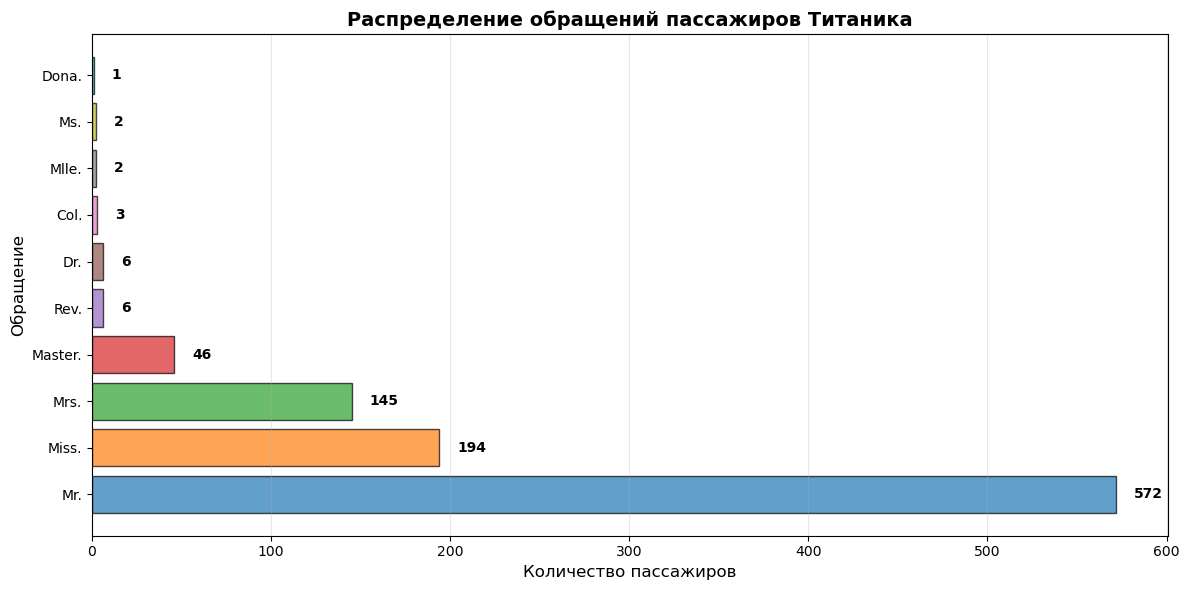

Итоговая структура датасета:
Размер: (981, 7)
Признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size', 'name', 'honorific']


In [35]:
# Визуализация распределения обращений
plt.figure(figsize=(12, 6))

# Топ-5 обращений
top_honorifics = honorific_counts.head(10)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

plt.barh(range(len(top_honorifics)), top_honorifics.values, color=colors[:len(top_honorifics)], alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_honorifics)), top_honorifics.index)
plt.xlabel('Количество пассажиров', fontsize=12)
plt.ylabel('Обращение', fontsize=12)
plt.title('Распределение обращений пассажиров Титаника', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(top_honorifics.values):
    plt.text(v + 10, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Итоговая структура датасета:")
print(f"Размер: {df_with_names.shape}")
print(f"Признаки: {list(df_with_names.columns)}")

In [36]:
# Сначала проверим особый случай с Countess
print("="*60)
print("ПРОВЕРКА ОСОБОГО СЛУЧАЯ:")
print("="*60)
special_name = df_with_names[df_with_names['honorific'].isnull()]
if len(special_name) > 0:
    print(f"Имя без обращения: {special_name['name'].values[0]}")
    # Извлекаем "Countess" для этого случая вручную
    df_with_names.loc[df_with_names['honorific'].isnull(), 'honorific'] = 'Countess.'
    print(f"Установлено обращение: Countess.")

print(f"\n{'='*60}")
print("ВСЕ ОБРАЩЕНИЯ ДО ЗАМЕН:")
print("="*60)
print(df_with_names['honorific'].value_counts())

ПРОВЕРКА ОСОБОГО СЛУЧАЯ:
Имя без обращения: Rothes, the Countess. of (Lucy Noel Martha Dyer-Edwards)
Установлено обращение: Countess.

ВСЕ ОБРАЩЕНИЯ ДО ЗАМЕН:
honorific
Mr.          572
Miss.        194
Mrs.         145
Master.       46
Rev.           6
Dr.            6
Col.           3
Mlle.          2
Ms.            2
Dona.          1
Countess.      1
Major.         1
Don.           1
Capt.          1
Name: count, dtype: int64


In [37]:
# Выполняем замены согласно указанным правилам

# Mr <- [Rev, Col, Dr, Major, Don, Capt]
df_with_names['honorific'] = df_with_names['honorific'].replace({
    'Rev.': 'Mr.',
    'Col.': 'Mr.',
    'Dr.': 'Mr.',
    'Major.': 'Mr.',
    'Don.': 'Mr.',
    'Capt.': 'Mr.'
})

# Mrs <- [Dona, Countess]
df_with_names['honorific'] = df_with_names['honorific'].replace({
    'Dona.': 'Mrs.',
    'Countess.': 'Mrs.'
})

# Miss <- [Mlle, Ms]
df_with_names['honorific'] = df_with_names['honorific'].replace({
    'Mlle.': 'Miss.',
    'Ms.': 'Miss.'
})

print("="*60)
print("ОБРАЩЕНИЯ ПОСЛЕ ЗАМЕН:")
print("="*60)
honorific_after = df_with_names['honorific'].value_counts()
print(honorific_after)

print(f"\n{'='*60}")
print("ИТОГО:")
print("="*60)
print(f"Число уникальных обращений после замен: {df_with_names['honorific'].nunique()}")
print(f"\nОбращения: {sorted(df_with_names['honorific'].unique())}")

# Статистика
total = len(df_with_names)
for hon in sorted(df_with_names['honorific'].unique()):
    count = (df_with_names['honorific'] == hon).sum()
    percent = (count / total) * 100
    print(f"  {hon:10s}: {count:3d} ({percent:.1f}%)")

ОБРАЩЕНИЯ ПОСЛЕ ЗАМЕН:
honorific
Mr.        590
Miss.      198
Mrs.       147
Master.     46
Name: count, dtype: int64

ИТОГО:
Число уникальных обращений после замен: 4

Обращения: ['Master.', 'Miss.', 'Mr.', 'Mrs.']
  Master.   :  46 (4.7%)
  Miss.     : 198 (20.2%)
  Mr.       : 590 (60.1%)
  Mrs.      : 147 (15.0%)


In [38]:
# Вычисляем долю строк со значением Master относительно числа всех мужчин
# Мужчины - это Mr. и Master.

num_master = (df_with_names['honorific'] == 'Master.').sum()
num_mr = (df_with_names['honorific'] == 'Mr.').sum()
num_all_males = num_master + num_mr

master_ratio = num_master / num_all_males

print("="*60)
print("АНАЛИЗ МУЖСКИХ ОБРАЩЕНИЙ:")
print("="*60)
print(f"Количество Master.: {num_master}")
print(f"Количество Mr.: {num_mr}")
print(f"Всего мужчин (Master + Mr): {num_all_males}")

print(f"\n{'='*60}")
print(f"ДОЛЯ Master ОТНОСИТЕЛЬНО ВСЕХ МУЖЧИН: {master_ratio:.6f}")
print(f"                                       {master_ratio*100:.2f}%")
print("="*60)

print(f"\nДополнительная информация:")
print(f"  Master составляет {master_ratio:.4f} или {master_ratio*100:.2f}% от всех мужчин")
print(f"  Mr составляет {(num_mr/num_all_males):.4f} или {(num_mr/num_all_males)*100:.2f}% от всех мужчин")

АНАЛИЗ МУЖСКИХ ОБРАЩЕНИЙ:
Количество Master.: 46
Количество Mr.: 590
Всего мужчин (Master + Mr): 636

ДОЛЯ Master ОТНОСИТЕЛЬНО ВСЕХ МУЖЧИН: 0.072327
                                       7.23%

Дополнительная информация:
  Master составляет 0.0723 или 7.23% от всех мужчин
  Mr составляет 0.9277 или 92.77% от всех мужчин


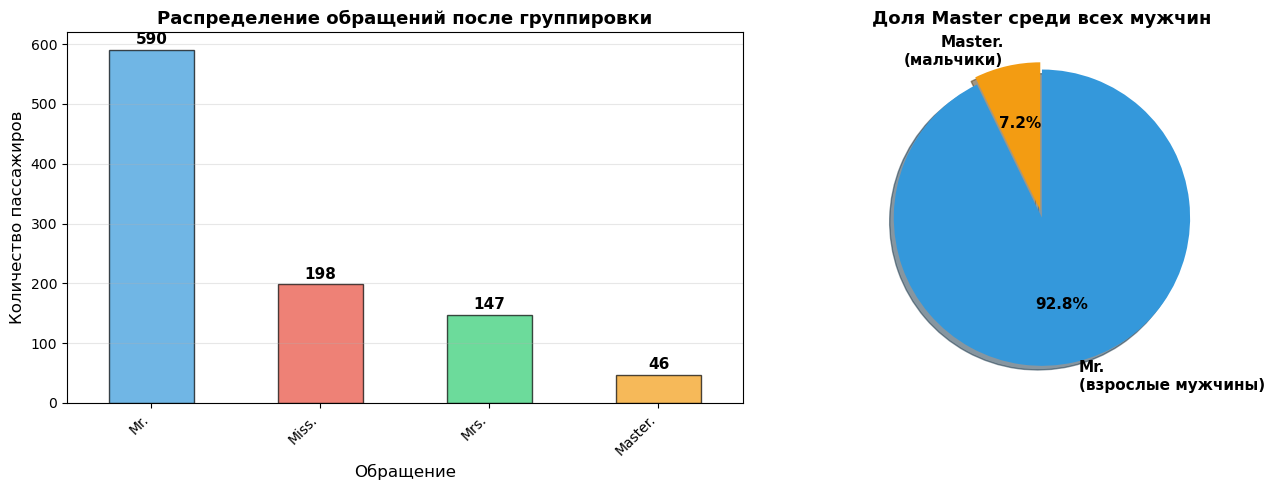

ИТОГОВАЯ СТАТИСТИКА:
Датасет размером: (981, 7)
Признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size', 'name', 'honorific']
Уникальных обращений: 4
Доля Master среди всех мужчин: 0.072327 (7.23%)


In [39]:
# Визуализация результатов после группировки
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Распределение обращений после группировки
ax1 = axes[0]
colors_final = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
honorific_after.plot(kind='bar', ax=ax1, color=colors_final, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Обращение', fontsize=12)
ax1.set_ylabel('Количество пассажиров', fontsize=12)
ax1.set_title('Распределение обращений после группировки', fontsize=13, fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, v in enumerate(honorific_after.values):
    ax1.text(i, v + 10, str(v), ha='center', fontsize=11, fontweight='bold')

# График 2: Доля Master среди мужчин
ax2 = axes[1]
labels = ['Master.\n(мальчики)', 'Mr.\n(взрослые мужчины)']
sizes = [num_master, num_mr]
colors_pie = ['#f39c12', '#3498db']
explode = (0.05, 0)

ax2.pie(sizes, explode=explode, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax2.set_title('Доля Master среди всех мужчин', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("="*60)
print("ИТОГОВАЯ СТАТИСТИКА:")
print("="*60)
print(f"Датасет размером: {df_with_names.shape}")
print(f"Признаки: {list(df_with_names.columns)}")
print(f"Уникальных обращений: {df_with_names['honorific'].nunique()}")
print(f"Доля Master среди всех мужчин: {master_ratio:.6f} ({master_ratio*100:.2f}%)")

In [40]:
# Вычисляем средний возраст категории Master
master_ages = df_with_names[df_with_names['honorific'] == 'Master.']['age']

# Убираем пропуски
master_ages_clean = master_ages.dropna()

# Вычисляем среднее
master_mean_age = master_ages_clean.mean()

print("="*60)
print("АНАЛИЗ ВОЗРАСТА КАТЕГОРИИ Master:")
print("="*60)
print(f"Всего пассажиров с обращением Master.: {len(master_ages)}")
print(f"Из них с известным возрастом: {len(master_ages_clean)}")
print(f"Пропусков возраста: {master_ages.isnull().sum()}")

print(f"\n{'='*60}")
print(f"СРЕДНИЙ ВОЗРАСТ Master: {master_mean_age:.6f} лет")
print(f"                        {master_mean_age:.2f} лет")
print("="*60)

# Дополнительная статистика
print(f"\nПодробная статистика возраста Master:")
print(master_ages_clean.describe())

print(f"\n{'='*60}")
print("РАСПРЕДЕЛЕНИЕ ВОЗРАСТОВ Master:")
print("="*60)
print(f"  Минимальный возраст: {master_ages_clean.min():.2f} лет")
print(f"  Максимальный возраст: {master_ages_clean.max():.2f} лет")
print(f"  Медианный возраст: {master_ages_clean.median():.2f} лет")
print(f"  Средний возраст: {master_mean_age:.2f} лет")
print(f"  Стандартное отклонение: {master_ages_clean.std():.2f} лет")

АНАЛИЗ ВОЗРАСТА КАТЕГОРИИ Master:
Всего пассажиров с обращением Master.: 46
Из них с известным возрастом: 39
Пропусков возраста: 7

СРЕДНИЙ ВОЗРАСТ Master: 5.128205 лет
                        5.13 лет

Подробная статистика возраста Master:
count    39.000000
mean      5.128205
std       3.863859
min       0.333300
25%       1.000000
50%       4.000000
75%       9.000000
max      13.000000
Name: age, dtype: float64

РАСПРЕДЕЛЕНИЕ ВОЗРАСТОВ Master:
  Минимальный возраст: 0.33 лет
  Максимальный возраст: 13.00 лет
  Медианный возраст: 4.00 лет
  Средний возраст: 5.13 лет
  Стандартное отклонение: 3.86 лет


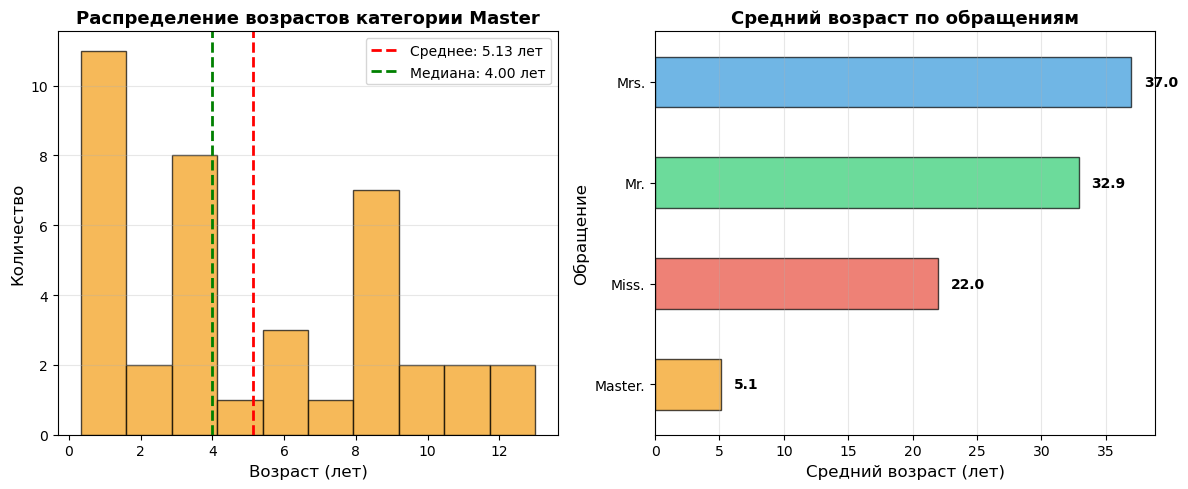

СРАВНЕНИЕ СРЕДНЕГО ВОЗРАСТА ПО ОБРАЩЕНИЯМ:
  Master.   : 5.13 лет (n=39)
  Miss.     : 22.01 лет (n=159)
  Mr.       : 32.90 лет (n=457)
  Mrs.      : 36.98 лет (n=127)


In [41]:
# Визуализация возраста Master
plt.figure(figsize=(12, 5))

# График 1: Гистограмма возрастов Master
plt.subplot(1, 2, 1)
plt.hist(master_ages_clean, bins=10, color='#f39c12', alpha=0.7, edgecolor='black')
plt.axvline(master_mean_age, color='red', linestyle='--', linewidth=2, label=f'Среднее: {master_mean_age:.2f} лет')
plt.axvline(master_ages_clean.median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {master_ages_clean.median():.2f} лет')
plt.xlabel('Возраст (лет)', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.title('Распределение возрастов категории Master', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# График 2: Сравнение среднего возраста разных категорий
plt.subplot(1, 2, 2)
age_by_honorific = df_with_names.groupby('honorific')['age'].mean().sort_values()
colors_bar = ['#f39c12', '#e74c3c', '#2ecc71', '#3498db']
age_by_honorific.plot(kind='barh', color=colors_bar, alpha=0.7, edgecolor='black')
plt.xlabel('Средний возраст (лет)', fontsize=12)
plt.ylabel('Обращение', fontsize=12)
plt.title('Средний возраст по обращениям', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Добавляем значения
for i, v in enumerate(age_by_honorific.values):
    plt.text(v + 1, i, f'{v:.1f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("="*60)
print("СРАВНЕНИЕ СРЕДНЕГО ВОЗРАСТА ПО ОБРАЩЕНИЯМ:")
print("="*60)
for hon in sorted(df_with_names['honorific'].unique()):
    ages = df_with_names[df_with_names['honorific'] == hon]['age'].dropna()
    if len(ages) > 0:
        print(f"  {hon:10s}: {ages.mean():.2f} лет (n={len(ages)})")

In [42]:
# Шаг 1: Вычисляем средний возраст для каждой категории honorific
mean_age_by_honorific = df_with_names.groupby('honorific')['age'].mean()

print("="*60)
print("СРЕДНИЙ ВОЗРАСТ ПО КАТЕГОРИЯМ HONORIFIC:")
print("="*60)
print(mean_age_by_honorific)

# Шаг 2: Заполняем пропуски в age средним по соответствующей категории
df_honorific_imputed = df_with_names.copy()

for honorific in df_honorific_imputed['honorific'].unique():
    mask = (df_honorific_imputed['honorific'] == honorific) & (df_honorific_imputed['age'].isnull())
    mean_age = mean_age_by_honorific[honorific]
    df_honorific_imputed.loc[mask, 'age'] = mean_age
    
    num_filled = mask.sum()
    if num_filled > 0:
        print(f"\n{honorific}: заполнено {num_filled} пропусков средним {mean_age:.2f} лет")

print(f"\n{'='*60}")
print("ПРОВЕРКА ПРОПУСКОВ ПОСЛЕ ЗАПОЛНЕНИЯ:")
print("="*60)
print(df_honorific_imputed.isnull().sum())

print(f"\nРазмер датасета: {df_honorific_imputed.shape}")

СРЕДНИЙ ВОЗРАСТ ПО КАТЕГОРИЯМ HONORIFIC:
honorific
Master.     5.128205
Miss.      22.005765
Mr.        32.900438
Mrs.       36.984252
Name: age, dtype: float64

Miss.: заполнено 39 пропусков средним 22.01 лет

Mrs.: заполнено 20 пропусков средним 36.98 лет

Mr.: заполнено 133 пропусков средним 32.90 лет

Master.: заполнено 7 пропусков средним 5.13 лет

ПРОВЕРКА ПРОПУСКОВ ПОСЛЕ ЗАПОЛНЕНИЯ:
pclass       0
survived     0
age          0
fare         0
fam_size     0
name         0
honorific    0
dtype: int64

Размер датасета: (981, 7)


In [43]:
# Шаг 3: Избавляемся от нечисловых признаков
df_numeric_v3 = df_honorific_imputed.select_dtypes(include=[np.number]).copy()

print("="*60)
print("ОТБОР ЧИСЛОВЫХ ПРИЗНАКОВ (версия 3):")
print("="*60)
print(f"Все признаки: {list(df_honorific_imputed.columns)}")
print(f"Числовые признаки: {list(df_numeric_v3.columns)}")
print(f"\nРазмер датасета: {df_numeric_v3.shape}")
print(f"Пропущенные значения:")
print(df_numeric_v3.isnull().sum())

print(f"\nПервые 5 строк:")
print(df_numeric_v3.head())

ОТБОР ЧИСЛОВЫХ ПРИЗНАКОВ (версия 3):
Все признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size', 'name', 'honorific']
Числовые признаки: ['pclass', 'survived', 'age', 'fare', 'fam_size']

Размер датасета: (981, 5)
Пропущенные значения:
pclass      0
survived    0
age         0
fare        0
fam_size    0
dtype: int64

Первые 5 строк:
   pclass  survived        age    fare  fam_size
0       3         1  22.005765  7.7333         0
1       3         1  22.005765  7.7500         0
2       3         1  38.000000  7.2292         0
3       3         0  22.000000  7.8958         0
4       3         0  16.000000  9.5000         0


In [44]:
# Шаг 4: Разделение на признаки и целевую переменную
X_v3 = df_numeric_v3.drop('survived', axis=1)
y_v3 = df_numeric_v3['survived']

print("="*60)
print("РАЗДЕЛЕНИЕ ДАННЫХ (версия 3 - honorific-based imputation):")
print("="*60)
print(f"Признаки (X): {list(X_v3.columns)}")
print(f"Целевая переменная (y): survived")
print(f"\nРазмер X: {X_v3.shape}")
print(f"Размер y: {y_v3.shape}")

# Шаг 5: Разбиение на обучающую и тестовую выборки со стратификацией
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, 
    test_size=0.2, 
    random_state=7, 
    stratify=y_v3
)

print(f"\n{'='*60}")
print("TRAIN-TEST SPLIT (версия 3):")
print("="*60)
print(f"Обучающая выборка: {X_train_v3.shape}")
print(f"Тестовая выборка: {X_test_v3.shape}")
print(f"\nРаспределение в обучающей выборке:")
print(y_train_v3.value_counts().sort_index())
print(f"Доля выживших: {y_train_v3.mean():.4f}")
print(f"\nРаспределение в тестовой выборке:")
print(y_test_v3.value_counts().sort_index())
print(f"Доля выживших: {y_test_v3.mean():.4f}")

РАЗДЕЛЕНИЕ ДАННЫХ (версия 3 - honorific-based imputation):
Признаки (X): ['pclass', 'age', 'fare', 'fam_size']
Целевая переменная (y): survived

Размер X: (981, 4)
Размер y: (981,)

TRAIN-TEST SPLIT (версия 3):
Обучающая выборка: (784, 4)
Тестовая выборка: (197, 4)

Распределение в обучающей выборке:
survived
0    484
1    300
Name: count, dtype: int64
Доля выживших: 0.3827

Распределение в тестовой выборке:
survived
0    122
1     75
Name: count, dtype: int64
Доля выживших: 0.3807


In [45]:
# Шаг 6: Обучение модели LogisticRegression
model_v3 = LogisticRegression(random_state=7, max_iter=1000)
model_v3.fit(X_train_v3, y_train_v3)

print("="*60)
print("ОБУЧЕНИЕ МОДЕЛИ (версия 3):")
print("="*60)
print("Модель: LogisticRegression(random_state=7, max_iter=1000)")
print("\nМодель обучена!")
print(f"\nКоэффициенты: {model_v3.coef_[0]}")
print(f"Признаки: {list(X_v3.columns)}")
print(f"Свободный член: {model_v3.intercept_[0]:.4f}")

ОБУЧЕНИЕ МОДЕЛИ (версия 3):
Модель: LogisticRegression(random_state=7, max_iter=1000)

Модель обучена!

Коэффициенты: [-0.76405641 -0.03894113  0.00626909 -0.04866617]
Признаки: ['pclass', 'age', 'fare', 'fam_size']
Свободный член: 2.2298


In [46]:
# Шаг 7: Оценка модели на тестовых данных
y_train_pred_v3 = model_v3.predict(X_train_v3)
y_test_pred_v3 = model_v3.predict(X_test_v3)

# Точность
train_acc_v3 = accuracy_score(y_train_v3, y_train_pred_v3)
test_acc_v3 = accuracy_score(y_test_v3, y_test_pred_v3)

# F1-score
train_f1_v3 = f1_score(y_train_v3, y_train_pred_v3)
test_f1_v3 = f1_score(y_test_v3, y_test_pred_v3)

print("="*60)
print("ОЦЕНКА МОДЕЛИ (версия 3 - honorific-based imputation):")
print("="*60)

print("\nТочность (Accuracy):")
print(f"  Обучающая выборка: {train_acc_v3:.4f} ({train_acc_v3*100:.2f}%)")
print(f"  Тестовая выборка: {test_acc_v3:.4f} ({test_acc_v3*100:.2f}%)")

print("\n" + "="*60)
print(f"F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: {test_f1_v3:.6f}")
print("="*60)

print(f"\nДополнительная информация:")
print(f"  F1-score (обучающая): {train_f1_v3:.6f}")
print(f"  F1-score (тестовая): {test_f1_v3:.6f}")

# Матрица ошибок
print(f"\n{'='*60}")
print("Матрица ошибок (тестовая выборка):")
print("="*60)
cm_v3 = confusion_matrix(y_test_v3, y_test_pred_v3)
print(cm_v3)
print(f"\nTN={cm_v3[0,0]}, FP={cm_v3[0,1]}, FN={cm_v3[1,0]}, TP={cm_v3[1,1]}")

print(f"\n{'='*60}")
print("Отчет классификации (тестовая выборка):")
print("="*60)
print(classification_report(y_test_v3, y_test_pred_v3, target_names=['Погиб', 'Выжил']))

ОЦЕНКА МОДЕЛИ (версия 3 - honorific-based imputation):

Точность (Accuracy):
  Обучающая выборка: 0.6888 (68.88%)
  Тестовая выборка: 0.6954 (69.54%)

F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: 0.464286

Дополнительная информация:
  F1-score (обучающая): 0.491667
  F1-score (тестовая): 0.464286

Матрица ошибок (тестовая выборка):
[[111  11]
 [ 49  26]]

TN=111, FP=11, FN=49, TP=26

Отчет классификации (тестовая выборка):
              precision    recall  f1-score   support

       Погиб       0.69      0.91      0.79       122
       Выжил       0.70      0.35      0.46        75

    accuracy                           0.70       197
   macro avg       0.70      0.63      0.63       197
weighted avg       0.70      0.70      0.66       197



In [47]:
# Сравнение всех трех подходов
print("="*70)
print("СРАВНЕНИЕ ТРЕХ ПОДХОДОВ К ОБРАБОТКЕ ПРОПУСКОВ:")
print("="*70)

comparison_data_full = {
    'Подход': [
        'Удаление строк с пропусками',
        'Заполнение общим средним',
        'Заполнение средним по honorific'
    ],
    'Обуч. выборка': [len(X_train), len(X_train_v2), len(X_train_v3)],
    'Тест. выборка': [len(X_test), len(X_test_v2), len(X_test_v3)],
    'Accuracy (тест)': [f"{test_acc:.4f}", f"{test_acc_v2:.4f}", f"{test_acc_v3:.4f}"],
    'F1-score (тест)': [f"{test_f1:.6f}", f"{test_f1_v2:.6f}", f"{test_f1_v3:.6f}"]
}

comparison_df_full = pd.DataFrame(comparison_data_full)
print(comparison_df_full.to_string(index=False))

print(f"\n{'='*70}")
print("ВЫВОДЫ:")
print("="*70)
print(f"1. Удаление пропусков:                   F1 = {test_f1:.6f}")
print(f"2. Заполнение общим средним:             F1 = {test_f1_v2:.6f}")
print(f"3. Заполнение средним по honorific:      F1 = {test_f1_v3:.6f}")
print(f"\nЛучший результат: Удаление пропусков (F1 = {test_f1:.6f})")
print(f"\nЗаполнение средним по honorific дало такой же результат,")
print(f"как и заполнение общим средним (F1 = {test_f1_v3:.6f}),")
print(f"но позволило использовать все 981 наблюдение.")

СРАВНЕНИЕ ТРЕХ ПОДХОДОВ К ОБРАБОТКЕ ПРОПУСКОВ:
                         Подход  Обуч. выборка  Тест. выборка Accuracy (тест) F1-score (тест)
    Удаление строк с пропусками            625            157          0.6815        0.528302
       Заполнение общим средним            784            197          0.6954        0.464286
Заполнение средним по honorific            784            197          0.6954        0.464286

ВЫВОДЫ:
1. Удаление пропусков:                   F1 = 0.528302
2. Заполнение общим средним:             F1 = 0.464286
3. Заполнение средним по honorific:      F1 = 0.464286

Лучший результат: Удаление пропусков (F1 = 0.528302)

Заполнение средним по honorific дало такой же результат,
как и заполнение общим средним (F1 = 0.464286),
но позволило использовать все 981 наблюдение.


In [48]:
# Шаг 1: Начинаем с исходного датасета и добавляем honorific
df_final = df_cleaned.copy()

# Извлекаем обращения (используем ту же функцию, что и раньше)
import re

def extract_honorific(name):
    """Извлекает обращение из имени пассажира"""
    match = re.search(r',\s+([A-Za-z]+\.)', name)
    if match:
        return match.group(1)
    return None

df_final['honorific'] = df_final['name'].apply(extract_honorific)

# Обрабатываем особый случай с Countess
df_final.loc[df_final['honorific'].isnull(), 'honorific'] = 'Countess.'

print("="*60)
print("ИСХОДНЫЙ ДАТАСЕТ С ОБРАЩЕНИЯМИ:")
print("="*60)
print(f"Размер: {df_final.shape}")
print(f"Признаки: {list(df_final.columns)}")
print(f"\nПропущенные значения:")
print(df_final.isnull().sum())

ИСХОДНЫЙ ДАТАСЕТ С ОБРАЩЕНИЯМИ:
Размер: (981, 9)
Признаки: ['pclass', 'survived', 'name', 'sex', 'age', 'fare', 'embarked', 'fam_size', 'honorific']

Пропущенные значения:
pclass         0
survived       0
name           0
sex            0
age          199
fare           0
embarked       0
fam_size       0
honorific      0
dtype: int64


In [49]:
# Шаг 2: Группируем обращения (как раньше)
df_final['honorific'] = df_final['honorific'].replace({
    'Rev.': 'Mr.',
    'Col.': 'Mr.',
    'Dr.': 'Mr.',
    'Major.': 'Mr.',
    'Don.': 'Mr.',
    'Capt.': 'Mr.',
    'Dona.': 'Mrs.',
    'Countess.': 'Mrs.',
    'Mlle.': 'Miss.',
    'Ms.': 'Miss.'
})

print("="*60)
print("ОБРАЩЕНИЯ ПОСЛЕ ГРУППИРОВКИ:")
print("="*60)
print(df_final['honorific'].value_counts())

# Шаг 3: Вычисляем средний возраст по категориям и заполняем пропуски
mean_age_by_honorific_final = df_final.groupby('honorific')['age'].mean()

print(f"\n{'='*60}")
print("СРЕДНИЙ ВОЗРАСТ ПО КАТЕГОРИЯМ:")
print("="*60)
print(mean_age_by_honorific_final)

for honorific in df_final['honorific'].unique():
    mask = (df_final['honorific'] == honorific) & (df_final['age'].isnull())
    mean_age = mean_age_by_honorific_final[honorific]
    num_filled = mask.sum()
    if num_filled > 0:
        df_final.loc[mask, 'age'] = mean_age
        print(f"\n{honorific}: заполнено {num_filled} пропусков средним {mean_age:.2f} лет")

print(f"\n{'='*60}")
print("ПРОВЕРКА ПРОПУСКОВ ПОСЛЕ ЗАПОЛНЕНИЯ:")
print("="*60)
print(df_final.isnull().sum())

ОБРАЩЕНИЯ ПОСЛЕ ГРУППИРОВКИ:
honorific
Mr.        590
Miss.      198
Mrs.       147
Master.     46
Name: count, dtype: int64

СРЕДНИЙ ВОЗРАСТ ПО КАТЕГОРИЯМ:
honorific
Master.     5.128205
Miss.      22.005765
Mr.        32.900438
Mrs.       36.984252
Name: age, dtype: float64

Miss.: заполнено 39 пропусков средним 22.01 лет

Mrs.: заполнено 20 пропусков средним 36.98 лет

Mr.: заполнено 133 пропусков средним 32.90 лет

Master.: заполнено 7 пропусков средним 5.13 лет

ПРОВЕРКА ПРОПУСКОВ ПОСЛЕ ЗАПОЛНЕНИЯ:
pclass       0
survived     0
name         0
sex          0
age          0
fare         0
embarked     0
fam_size     0
honorific    0
dtype: int64


In [50]:
# Шаг 4: Выбрасываем признаки name и honorific
df_final = df_final.drop(columns=['name', 'honorific'])

print("="*60)
print("ДАТАСЕТ ПОСЛЕ УДАЛЕНИЯ name И honorific:")
print("="*60)
print(f"Размер: {df_final.shape}")
print(f"Признаки: {list(df_final.columns)}")
print(f"\nПервые 5 строк:")
print(df_final.head())

print(f"\n{'='*60}")
print("ТИПЫ ДАННЫХ:")
print("="*60)
print(df_final.dtypes)

ДАТАСЕТ ПОСЛЕ УДАЛЕНИЯ name И honorific:
Размер: (981, 7)
Признаки: ['pclass', 'survived', 'sex', 'age', 'fare', 'embarked', 'fam_size']

Первые 5 строк:
   pclass  survived     sex        age    fare embarked  fam_size
0       3         1  female  22.005765  7.7333        Q         0
1       3         1  female  22.005765  7.7500        Q         0
2       3         1  female  38.000000  7.2292        C         0
3       3         0    male  22.000000  7.8958        S         0
4       3         0    male  16.000000  9.5000        S         0

ТИПЫ ДАННЫХ:
pclass        int64
survived      int64
sex          object
age         float64
fare        float64
embarked     object
fam_size      int64
dtype: object


In [51]:
# Шаг 5: One-hot кодирование нечисловых признаков
# Сначала отделяем целевую переменную
y_final = df_final['survived']
X_final = df_final.drop('survived', axis=1)

print("="*60)
print("BEFORE ONE-HOT ENCODING:")
print("="*60)
print(f"Размер X: {X_final.shape}")
print(f"Признаки: {list(X_final.columns)}")
print(f"Нечисловые признаки: {list(X_final.select_dtypes(include=['object']).columns)}")

# One-hot кодирование с drop_first=True
X_final_encoded = pd.get_dummies(X_final, drop_first=True)

print(f"\n{'='*60}")
print("AFTER ONE-HOT ENCODING:")
print("="*60)
print(f"Размер X: {X_final_encoded.shape}")
print(f"Признаки: {list(X_final_encoded.columns)}")
print(f"\nПервые 5 строк:")
print(X_final_encoded.head())

print(f"\nПропущенные значения:")
print(X_final_encoded.isnull().sum())

BEFORE ONE-HOT ENCODING:
Размер X: (981, 6)
Признаки: ['pclass', 'sex', 'age', 'fare', 'embarked', 'fam_size']
Нечисловые признаки: ['sex', 'embarked']

AFTER ONE-HOT ENCODING:
Размер X: (981, 7)
Признаки: ['pclass', 'age', 'fare', 'fam_size', 'sex_male', 'embarked_Q', 'embarked_S']

Первые 5 строк:
   pclass        age    fare  fam_size  sex_male  embarked_Q  embarked_S
0       3  22.005765  7.7333         0     False        True       False
1       3  22.005765  7.7500         0     False        True       False
2       3  38.000000  7.2292         0     False       False       False
3       3  22.000000  7.8958         0      True       False        True
4       3  16.000000  9.5000         0      True       False        True

Пропущенные значения:
pclass        0
age           0
fare          0
fam_size      0
sex_male      0
embarked_Q    0
embarked_S    0
dtype: int64


In [52]:
# Шаг 6: Разбиение на обучающую и тестовую выборки
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final_encoded, y_final, 
    test_size=0.2, 
    random_state=7, 
    stratify=y_final
)

print("="*60)
print("TRAIN-TEST SPLIT (финальная версия):")
print("="*60)
print(f"Обучающая выборка: {X_train_final.shape}")
print(f"Тестовая выборка: {X_test_final.shape}")
print(f"\nРаспределение в обучающей выборке:")
print(y_train_final.value_counts().sort_index())
print(f"Доля выживших: {y_train_final.mean():.4f}")
print(f"\nРаспределение в тестовой выборке:")
print(y_test_final.value_counts().sort_index())
print(f"Доля выживших: {y_test_final.mean():.4f}")

TRAIN-TEST SPLIT (финальная версия):
Обучающая выборка: (784, 7)
Тестовая выборка: (197, 7)

Распределение в обучающей выборке:
survived
0    484
1    300
Name: count, dtype: int64
Доля выживших: 0.3827

Распределение в тестовой выборке:
survived
0    122
1     75
Name: count, dtype: int64
Доля выживших: 0.3807


In [53]:
# Шаг 7: Обучение модели LogisticRegression
model_final = LogisticRegression(random_state=7, max_iter=1000)
model_final.fit(X_train_final, y_train_final)

print("="*60)
print("ОБУЧЕНИЕ МОДЕЛИ (финальная версия с one-hot encoding):")
print("="*60)
print("Модель: LogisticRegression(random_state=7, max_iter=1000)")
print("\nМодель обучена!")
print(f"\nКоэффициенты: {model_final.coef_[0]}")
print(f"Признаки: {list(X_final_encoded.columns)}")
print(f"Свободный член: {model_final.intercept_[0]:.4f}")

# Важность признаков
print(f"\n{'='*60}")
print("ВАЖНОСТЬ ПРИЗНАКОВ:")
print("="*60)
feature_importance_final = pd.DataFrame({
    'Признак': X_final_encoded.columns,
    'Коэффициент': model_final.coef_[0],
    'Абс. значение': np.abs(model_final.coef_[0])
}).sort_values('Абс. значение', ascending=False)
print(feature_importance_final.to_string(index=False))

ОБУЧЕНИЕ МОДЕЛИ (финальная версия с one-hot encoding):
Модель: LogisticRegression(random_state=7, max_iter=1000)

Модель обучена!

Коэффициенты: [-0.79580598 -0.03704311  0.00340767 -0.22659943 -2.66315619 -0.90507423
 -0.6653416 ]
Признаки: ['pclass', 'age', 'fare', 'fam_size', 'sex_male', 'embarked_Q', 'embarked_S']
Свободный член: 4.6294

ВАЖНОСТЬ ПРИЗНАКОВ:
   Признак  Коэффициент  Абс. значение
  sex_male    -2.663156       2.663156
embarked_Q    -0.905074       0.905074
    pclass    -0.795806       0.795806
embarked_S    -0.665342       0.665342
  fam_size    -0.226599       0.226599
       age    -0.037043       0.037043
      fare     0.003408       0.003408


In [54]:
# Шаг 8: Оценка модели на тестовых данных
y_train_pred_final = model_final.predict(X_train_final)
y_test_pred_final = model_final.predict(X_test_final)

# Точность
train_acc_final = accuracy_score(y_train_final, y_train_pred_final)
test_acc_final = accuracy_score(y_test_final, y_test_pred_final)

# F1-score
train_f1_final = f1_score(y_train_final, y_train_pred_final)
test_f1_final = f1_score(y_test_final, y_test_pred_final)

print("="*60)
print("ОЦЕНКА МОДЕЛИ (с one-hot encoding):")
print("="*60)

print("\nТочность (Accuracy):")
print(f"  Обучающая выборка: {train_acc_final:.4f} ({train_acc_final*100:.2f}%)")
print(f"  Тестовая выборка: {test_acc_final:.4f} ({test_acc_final*100:.2f}%)")

print("\n" + "="*60)
print(f"F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: {test_f1_final:.6f}")
print("="*60)

print(f"\nДополнительная информация:")
print(f"  F1-score (обучающая): {train_f1_final:.6f}")
print(f"  F1-score (тестовая): {test_f1_final:.6f}")

# Матрица ошибок
print(f"\n{'='*60}")
print("Матрица ошибок (тестовая выборка):")
print("="*60)
cm_final = confusion_matrix(y_test_final, y_test_pred_final)
print(cm_final)
print(f"\nTN={cm_final[0,0]}, FP={cm_final[0,1]}, FN={cm_final[1,0]}, TP={cm_final[1,1]}")

print(f"\n{'='*60}")
print("Отчет классификации (тестовая выборка):")
print("="*60)
print(classification_report(y_test_final, y_test_pred_final, target_names=['Погиб', 'Выжил']))

ОЦЕНКА МОДЕЛИ (с one-hot encoding):

Точность (Accuracy):
  Обучающая выборка: 0.8099 (80.99%)
  Тестовая выборка: 0.7107 (71.07%)

F1-SCORE НА ТЕСТОВЫХ ДАННЫХ: 0.577778

Дополнительная информация:
  F1-score (обучающая): 0.744425
  F1-score (тестовая): 0.577778

Матрица ошибок (тестовая выборка):
[[101  21]
 [ 36  39]]

TN=101, FP=21, FN=36, TP=39

Отчет классификации (тестовая выборка):
              precision    recall  f1-score   support

       Погиб       0.74      0.83      0.78       122
       Выжил       0.65      0.52      0.58        75

    accuracy                           0.71       197
   macro avg       0.69      0.67      0.68       197
weighted avg       0.70      0.71      0.70       197



In [55]:
# Сравнение ВСЕХ подходов
print("="*80)
print("СРАВНЕНИЕ ВСЕХ ПОДХОДОВ:")
print("="*80)

comparison_all = {
    'Подход': [
        '1. Только числовые + удаление пропусков',
        '2. Только числовые + общее среднее',
        '3. Только числовые + среднее по honorific',
        '4. Все признаки + one-hot encoding'
    ],
    'Признаков': [4, 4, 4, 7],
    'Обуч.': [625, 784, 784, 784],
    'Тест': [157, 197, 197, 197],
    'Accuracy': [
        f"{test_acc:.4f}",
        f"{test_acc_v2:.4f}",
        f"{test_acc_v3:.4f}",
        f"{test_acc_final:.4f}"
    ],
    'F1-score': [
        f"{test_f1:.6f}",
        f"{test_f1_v2:.6f}",
        f"{test_f1_v3:.6f}",
        f"{test_f1_final:.6f}"
    ]
}

comparison_all_df = pd.DataFrame(comparison_all)
print(comparison_all_df.to_string(index=False))

print(f"\n{'='*80}")
print("ИТОГОВЫЕ ВЫВОДЫ:")
print("="*80)
print(f"Лучший результат: Подход 4 (все признаки + one-hot encoding)")
print(f"  • F1-score: {test_f1_final:.6f}")
print(f"  • Accuracy: {test_acc_final:.4f}")
print(f"  • Использует категориальные признаки (sex, embarked)")
print(f"  • sex_male имеет самый сильный отрицательный коэффициент (-2.66)")
print(f"  • Это подтверждает важность пола для предсказания выживаемости")
print(f"\nУлучшение по сравнению с лучшим числовым подходом:")
print(f"  • F1-score: {test_f1_final:.6f} vs {test_f1:.6f} (+{test_f1_final - test_f1:.6f})")
print(f"  • Accuracy: {test_acc_final:.4f} vs {test_acc:.4f} (+{test_acc_final - test_acc:.4f})")

СРАВНЕНИЕ ВСЕХ ПОДХОДОВ:
                                   Подход  Признаков  Обуч.  Тест Accuracy F1-score
  1. Только числовые + удаление пропусков          4    625   157   0.6815 0.528302
       2. Только числовые + общее среднее          4    784   197   0.6954 0.464286
3. Только числовые + среднее по honorific          4    784   197   0.6954 0.464286
       4. Все признаки + one-hot encoding          7    784   197   0.7107 0.577778

ИТОГОВЫЕ ВЫВОДЫ:
Лучший результат: Подход 4 (все признаки + one-hot encoding)
  • F1-score: 0.577778
  • Accuracy: 0.7107
  • Использует категориальные признаки (sex, embarked)
  • sex_male имеет самый сильный отрицательный коэффициент (-2.66)
  • Это подтверждает важность пола для предсказания выживаемости

Улучшение по сравнению с лучшим числовым подходом:
  • F1-score: 0.577778 vs 0.528302 (+0.049476)
  • Accuracy: 0.7107 vs 0.6815 (+0.0291)
